<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/18_NeuroFHIR_SAFE_Integrated_WISH_Results_and_Figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 18 — NeuroFHIR-SAFE
## Integrated WISH Results, Figures, and GO/NO-GO Package

This notebook combines:

- **16A:** formal Evidence-First verification + AI-First counterexample + M1–M9 mutation testing;
- **16B:** running-application trace conformance + FHIR audit;
- **17:** optional 1–2 expert formative walkthroughs.

The expert layer is supportive. The formal + executable + FHIR core must stand on its own.

In [1]:
# Cell 1 — Mount Drive / load result roots
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json, pandas as pd, datetime, textwrap
import matplotlib.pyplot as plt

DRIVE_REPO_ROOT = Path("/content/drive/MyDrive/neurofhir-qc")
SAFE_ROOT = DRIVE_REPO_ROOT / "wish_extension" / "neurofhir_safe"

FORMAL_ROOT = SAFE_ROOT / "artifacts" / "formal"
IMPL_ROOT = SAFE_ROOT / "artifacts" / "implementation"
EXPERT_ROOT = SAFE_ROOT / "artifacts" / "expert_walkthrough"
FINAL_ROOT = SAFE_ROOT / "artifacts" / "integrated_wish"
FINAL_ROOT.mkdir(parents=True, exist_ok=True)

formal_path = FORMAL_ROOT / "formal_results.json"
impl_path = IMPL_ROOT / "implementation_summary.json"
expert_path = EXPERT_ROOT / "expert_walkthrough_summary.json"

assert formal_path.exists(), "Notebook 16A output missing."
assert impl_path.exists(), "Notebook 16B output missing."

formal = json.loads(formal_path.read_text(encoding="utf-8"))
impl = json.loads(impl_path.read_text(encoding="utf-8"))
expert = (
    json.loads(expert_path.read_text(encoding="utf-8"))
    if expert_path.exists() else None
)

print("Formal core: loaded")
print("Implementation/FHIR: loaded")
print("Expert layer:", "loaded" if expert else "not present (optional)")

Mounted at /content/drive
Formal core: loaded
Implementation/FHIR: loaded
Expert layer: not present (optional)


In [2]:
# Cell 2 — Formal result table

prop_df = pd.DataFrame(formal["properties"])
prop_df["Evidence-First"] = "Verified"
prop_df["AI-First comparator"] = prop_df["property_id"].map(
    lambda x: "Counterexample" if x == "P1" else "Not primary comparator endpoint"
)

display(prop_df[[
    "property_id","name","plain_language_requirement",
    "Evidence-First","AI-First comparator"
]])

prop_df.to_csv(FINAL_ROOT / "table_formal_properties.csv", index=False)

,property_id,name,plain_language_requirement,Evidence-First,AI-First comparator
0,P1,Human-First ordering,AI advice must never appear before an independ...,Verified,Counterexample
1,P2,Uncertainty co-presentation,AI advice cannot appear without its QC/uncerta...,Verified,Not primary comparator endpoint
2,P3,Low-QC finalization block,Low/failed-QC evidence cannot silently become ...,Verified,Not primary comparator endpoint
3,P4,Conflict handling,Known longitudinal conflict must be acknowledg...,Verified,Not primary comparator endpoint
4,P5,Model identity,Final AI-derived evidence must remain bound to...,Verified,Not primary comparator endpoint
5,P6,Provenance completeness,Accepted or rejected evidence must preserve li...,Verified,Not primary comparator endpoint
6,P7,Human authorization,AI cannot finalize evidence without explicit h...,Verified,Not primary comparator endpoint
7,P8,Rejection preservation,Rejected evidence remains reconstructable.,Verified,Not primary comparator endpoint
8,P9,Escalation safety,Escalated cases remain non-final.,Verified,Not primary comparator endpoint
9,P10,Task-state consistency,FHIR-style review workflow state must agree wi...,Verified,Not primary comparator endpoint


In [3]:
# Cell 3 — Mutation table

mutation_path = FORMAL_ROOT / "mutation_results.csv"
mutation_df = pd.read_csv(mutation_path)
display(mutation_df)

detected = int(mutation_df["detected"].fillna(False).astype(bool).sum())
total = int(len(mutation_df))

print(f"Mutation detection: {detected}/{total}")
mutation_df.to_csv(FINAL_ROOT / "table_mutation_results.csv", index=False)

,mutant,expected_property,observed_violation,detected,states_generated,distinct_states,log
0,M1_early_ai,P1,P1,True,26,26,/content/drive/MyDrive/neurofhir-qc/wish_exten...
1,M2_hide_uncertainty,P2,P2,True,74,74,/content/drive/MyDrive/neurofhir-qc/wish_exten...
2,M3_low_qc_final,P3,P3,True,157,155,/content/drive/MyDrive/neurofhir-qc/wish_exten...
3,M4_unack_conflict,P4,P4,True,193,189,/content/drive/MyDrive/neurofhir-qc/wish_exten...
4,M5_no_model_identity,P5,P5,True,171,169,/content/drive/MyDrive/neurofhir-qc/wish_exten...
5,M6_no_provenance_reject,P6,P6,True,122,122,/content/drive/MyDrive/neurofhir-qc/wish_exten...
6,M7_ai_autofinal,P7,P7,True,98,98,/content/drive/MyDrive/neurofhir-qc/wish_exten...
7,M8_final_escalation,P9,P9,True,121,121,/content/drive/MyDrive/neurofhir-qc/wish_exten...
8,M9_task_mismatch,P10,P10,True,123,123,/content/drive/MyDrive/neurofhir-qc/wish_exten...


Mutation detection: 9/9


In [4]:
# Cell 4 — Runtime and FHIR tables

runtime_path = IMPL_ROOT / "runtime_trace_audit.csv"
fhir_path = IMPL_ROOT / "fhir_safety_audit.csv"

runtime_df = pd.read_csv(runtime_path) if runtime_path.exists() else pd.DataFrame()
fhir_df = pd.read_csv(fhir_path) if fhir_path.exists() else pd.DataFrame()

print("Runtime rows:", len(runtime_df))
print("FHIR assertions:", len(fhir_df))

display(runtime_df.head(30))
display(fhir_df.head(30))

runtime_df.to_csv(FINAL_ROOT / "table_runtime_trace_conformance.csv", index=False)
fhir_df.to_csv(FINAL_ROOT / "table_fhir_safety_audit.csv", index=False)

Runtime rows: 24
FHIR assertions: 608


,participant_id,case_id,declared_condition,observed_architecture,initial_event_index,ai_event_index,provenance_event_index,final_event_index,order_trace_complete,human_first_order_observed,ai_first_order_observed,final_after_ai
0,P001,S01,evidence-first,AI-First,135,132,NaN,NaN,True,False,True,False
1,P001,S02,ai-first,AI-First,4,0,NaN,NaN,True,False,True,False
2,P001,S03,ai-first,AI-First,16,12,NaN,NaN,True,False,True,False
3,P001,S04,evidence-first,AI-First,75,72,NaN,NaN,True,False,True,False
4,P001,S05,evidence-first,AI-First,63,60,NaN,NaN,True,False,True,False
5,P001,S06,ai-first,AI-First,52,48,NaN,NaN,True,False,True,False
6,P001,S07,ai-first,AI-First,40,36,NaN,NaN,True,False,True,False
7,P001,S08,evidence-first,AI-First,27,24,NaN,NaN,True,False,True,False
8,P001,S09,evidence-first,AI-First,111,108,NaN,NaN,True,False,True,False
9,P001,S10,ai-first,AI-First,88,84,NaN,NaN,True,False,True,False


,source_file,check,passed,resource_types,terminal_results,details
0,/content/drive/MyDrive/neurofhir-qc/wish_exten...,has_device_identity,False,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
1,/content/drive/MyDrive/neurofhir-qc/wish_exten...,terminal_results_have_provenance,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
2,/content/drive/MyDrive/neurofhir-qc/wish_exten...,final_has_completed_task,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
3,/content/drive/MyDrive/neurofhir-qc/wish_exten...,rejected_has_rejected_task,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
4,/content/drive/MyDrive/neurofhir-qc/app/fronte...,has_device_identity,False,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
5,/content/drive/MyDrive/neurofhir-qc/app/fronte...,terminal_results_have_provenance,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
6,/content/drive/MyDrive/neurofhir-qc/app/fronte...,final_has_completed_task,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
7,/content/drive/MyDrive/neurofhir-qc/app/fronte...,rejected_has_rejected_task,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
8,/content/drive/MyDrive/neurofhir-qc/app/fronte...,has_device_identity,False,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN
9,/content/drive/MyDrive/neurofhir-qc/app/fronte...,terminal_results_have_provenance,True,"DiagnosticReport,Observation,Practitioner,Prov...",6,NaN


In [5]:
# Cell 5 — Optional expert-validation table

if expert:
    print("Expert reviewers:", expert["reviewer_count"])
    print("Completed case reviews:", expert["completed_case_reviews"])
    expert_rating_df = pd.DataFrame(expert["descriptive_ratings"])
    display(expert_rating_df)
    expert_rating_df.to_csv(
        FINAL_ROOT / "table_expert_formative_summary.csv",
        index=False
    )
else:
    expert_rating_df = pd.DataFrame()
    print("No expert walkthrough included. Core study remains interpretable.")

No expert walkthrough included. Core study remains interpretable.


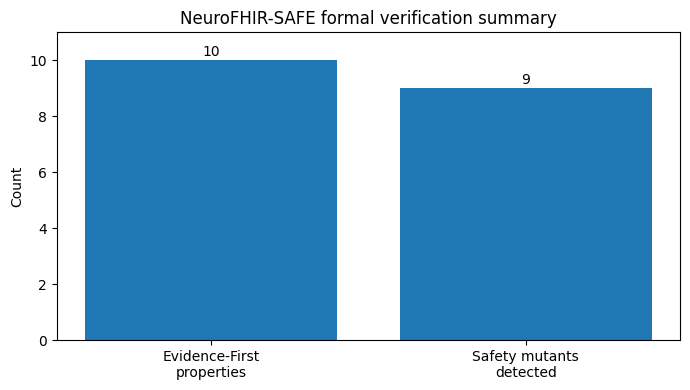

/content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish/figure_formal_summary.png


In [6]:
# Cell 6 — Figure 1: formal verification / mutation detection summary

labels = ["Evidence-First\nproperties", "Safety mutants\ndetected"]
values = [
    10,
    detected,
]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(labels, values)
ax.set_ylabel("Count")
ax.set_title("NeuroFHIR-SAFE formal verification summary")
ax.set_ylim(0, max(10, total) + 1)

for i, v in enumerate(values):
    ax.text(i, v + 0.15, str(v), ha="center")

fig.tight_layout()
fig1 = FINAL_ROOT / "figure_formal_summary.png"
fig.savefig(fig1, dpi=180)
plt.show()

print(fig1)

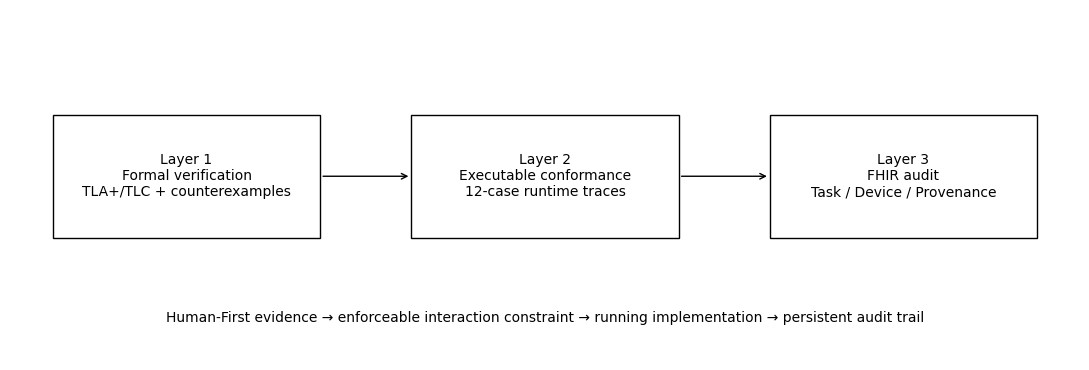

/content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish/figure_three_layer_architecture.png


In [7]:
# Cell 7 — Figure 2: three-layer evidence architecture

fig, ax = plt.subplots(figsize=(11,3.8))
ax.axis("off")

boxes = [
    (0.04, 0.35, 0.25, 0.35, "Layer 1\nFormal verification\nTLA+/TLC + counterexamples"),
    (0.375, 0.35, 0.25, 0.35, "Layer 2\nExecutable conformance\n12-case runtime traces"),
    (0.71, 0.35, 0.25, 0.35, "Layer 3\nFHIR audit\nTask / Device / Provenance"),
]

for x, y, w, h, label in boxes:
    rect = plt.Rectangle((x,y), w,h, fill=False)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, label, ha="center", va="center")

ax.annotate("", xy=(0.375,0.525), xytext=(0.29,0.525),
            arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.71,0.525), xytext=(0.625,0.525),
            arrowprops=dict(arrowstyle="->"))

ax.text(
    0.5, 0.12,
    "Human-First evidence → enforceable interaction constraint → running implementation → persistent audit trail",
    ha="center", va="center"
)

fig.tight_layout()
fig2 = FINAL_ROOT / "figure_three_layer_architecture.png"
fig.savefig(fig2, dpi=180)
plt.show()

print(fig2)

In [8]:
# Cell 8 — GO / NO-GO gate

formal_ok = (
    formal["evidence_first"]["violated_property"] is None
    and formal["mutation_detection"]["detected"] == formal["mutation_detection"]["total"]
    and formal["ai_first"]["violated_property"] == "P1"
)

runtime_rate = impl["runtime"].get("evidence_first_order_conformance_rate")
runtime_ok = (
    runtime_rate == 1.0
    and impl["runtime"].get("evidence_first_traces", 0) > 0
)

fhir_rate = impl["fhir"].get("pass_rate")
fhir_ok = (
    fhir_rate == 1.0
    and impl["fhir"].get("assertions", 0) > 0
)

expert_ok = (
    expert is not None
    and expert.get("reviewer_count", 0) in [1,2]
    and expert.get("completed_case_reviews", 0) >= 4
)

gate_df = pd.DataFrame([
    ["Formal Evidence-First P1–P10 + AI-First counterexample + mutants", formal_ok, "Required"],
    ["Running implementation trace conformance", runtime_ok, "Required"],
    ["FHIR safety/provenance audit", fhir_ok, "Required for strongest end-to-end claim"],
    ["1–2 expert formative walkthroughs", expert_ok, "Optional strengthening"],
], columns=["component","passed","role"])

display(gate_df)

gate_df.to_csv(FINAL_ROOT / "go_no_go_gate.csv", index=False)

,component,passed,role
0,Formal Evidence-First P1–P10 + AI-First counte...,True,Required
1,Running implementation trace conformance,False,Required
2,FHIR safety/provenance audit,False,Required for strongest end-to-end claim
3,1–2 expert formative walkthroughs,False,Optional strengthening


In [9]:
# Cell 9 — Generate bounded manuscript-ready result language

if formal_ok and runtime_ok and fhir_ok:
    core_status = "STRONGEST CORE COMPLETE"
elif formal_ok and runtime_ok:
    core_status = "FORMAL + RUNTIME COMPLETE; FHIR LAYER INCOMPLETE"
elif formal_ok:
    core_status = "FORMAL CORE COMPLETE; IMPLEMENTATION VALIDATION INCOMPLETE"
else:
    core_status = "NO-GO: FORMAL CORE INCOMPLETE"

expert_sentence = (
    f"A formative expert walkthrough included {expert['reviewer_count']} expert reviewer(s) "
    f"across {expert['completed_case_reviews']} completed case reviews. "
    "These data were treated as face-validity/usability feedback rather than behavioral-effect estimates."
    if expert_ok else
    "No expert walkthrough was included in the primary results; human evaluation remains a future validation step."
)

results_text = f"""
# NeuroFHIR-SAFE — Integrated Results Status

**Status:** {core_status}

The Evidence-First finite workflow model was evaluated against ten explicit
interaction-safety properties. The controlled AI-First comparator was used to
test Human-First ordering, and deliberate safeguard mutations were used to
evaluate whether the verification pipeline could detect meaningful regressions.

Mutation detection: **{detected}/{total}** intentional regressions detected.

Evidence-First runtime-order conformance:
**{runtime_rate if runtime_rate is not None else 'not yet available'}**.

FHIR safety-audit pass rate:
**{fhir_rate if fhir_rate is not None else 'not yet available'}**.

{expert_sentence}

## Claim boundary

These results support a pre-deployment interaction-safety and implementation-
conformance claim. They do **not** establish that Evidence-First presentation
improves clinician accuracy, reduces real-world anchoring, improves patient
outcomes, or makes the deployed system clinically proven safe.
"""

results_md = FINAL_ROOT / "integrated_results_summary.md"
results_md.write_text(textwrap.dedent(results_text).strip() + "\n", encoding="utf-8")

print(results_text)


# NeuroFHIR-SAFE — Integrated Results Status

**Status:** FORMAL CORE COMPLETE; IMPLEMENTATION VALIDATION INCOMPLETE

The Evidence-First finite workflow model was evaluated against ten explicit
interaction-safety properties. The controlled AI-First comparator was used to
test Human-First ordering, and deliberate safeguard mutations were used to
evaluate whether the verification pipeline could detect meaningful regressions.

Mutation detection: **9/9** intentional regressions detected.

Evidence-First runtime-order conformance:
**not yet available**.

FHIR safety-audit pass rate:
**0.7615131578947368**.

No expert walkthrough was included in the primary results; human evaluation remains a future validation step.

## Claim boundary

These results support a pre-deployment interaction-safety and implementation-
conformance claim. They do **not** establish that Evidence-First presentation
improves clinician accuracy, reduces real-world anchoring, improves patient
outcomes, or makes the dep

In [10]:
# Cell 10 — WISH-ready 1–2 page structure populated from actual outputs

wish_outline = f"""
# Working title
**Can Human-First Be Enforced? Formal Verification of an Evidence-First Clinical AI Review Workflow**

## Problem
Human-centered AI evidence suggests that decision order can shape deference to AI,
but a design recommendation does not guarantee that a deployed workflow preserves
the intended ordering across edge cases, error states, or software changes.

## Objective
Translate Human-First clinical-AI principles into explicit interaction-safety
properties, verify those properties over a finite workflow model, and test whether
the running NeuroFHIR-Review implementation and FHIR audit trail conform.

## Methods
- P1–P10 interaction-safety properties.
- TLA+/TLC finite-state verification.
- Controlled AI-First comparator.
- M1–M9 deliberate safeguard mutations.
- Existing 12-case executable workflow traces.
- Runtime trace-conformance audit.
- FHIR Task/Device/Provenance consistency audit.
- Optional 1–2 expert formative walkthroughs.

## Results snapshot
- Evidence-First formal core: {"PASS" if formal_ok else "INCOMPLETE"}.
- AI-First P1 counterexample: {"DETECTED" if formal["ai_first"]["violated_property"] == "P1" else "NOT DETECTED"}.
- Mutation detection: {detected}/{total}.
- Runtime Evidence-First order conformance: {runtime_rate}.
- FHIR audit pass rate: {fhir_rate}.
- Expert formative layer: {"included" if expert_ok else "not included / incomplete"}.

## Contribution
A reproducible pre-deployment method for converting empirically motivated
Human-First design principles into machine-testable interaction constraints and
checking that those constraints survive implementation and interoperable write-back.

## Claim boundary
No claim of improved diagnostic accuracy, reduced real-world anchoring, clinical
effectiveness, or proven clinical safety.
"""

wish_path = FINAL_ROOT / "WISH_1to2_page_results_outline.md"
wish_path.write_text(textwrap.dedent(wish_outline).strip() + "\n", encoding="utf-8")

print("✅ WISH outline:", wish_path)

✅ WISH outline: /content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish/WISH_1to2_page_results_outline.md


In [11]:
# Cell 11 — Final decision

print("=" * 84)
print("NEUROFHIR-SAFE — FINAL STUDY DECISION")
print("=" * 84)

if formal_ok and runtime_ok and fhir_ok and expert_ok:
    print("✅ GO — strongest package: formal core + implementation/FHIR + expert walkthrough.")
elif formal_ok and runtime_ok and fhir_ok:
    print("✅ GO — strongest no-human core complete.")
    print("   Expert walkthrough remains optional supportive validation.")
elif formal_ok and runtime_ok:
    print("⚠️ GO WITH CAUTION — formal + runtime complete, FHIR end-to-end layer incomplete.")
else:
    print("❌ NO-GO for strongest claim. Complete the failed required layers first.")

print("=" * 84)
print("Outputs:", FINAL_ROOT)

NEUROFHIR-SAFE — FINAL STUDY DECISION
❌ NO-GO for strongest claim. Complete the failed required layers first.
Outputs: /content/drive/MyDrive/neurofhir-qc/wish_extension/neurofhir_safe/artifacts/integrated_wish
